In [18]:
from pathlib import Path

path = Path('/mnt/nas/nas3/openData/rawdata/4dFlow/ChallengeData/TaskR1R2/ValidationSet/Aorta/Center007/GE_30T_Architect/P088')
acceleration = 50
sense_niter = 5
sense_lam = 1e-4


In [19]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


def load_mat(path, key, complex_mode='auto'):
    class _Lazy:
        def __init__(self, path, key):
            self._f = h5py.File(path, 'r')
            self.dset = self._f[key]

        @property
        def shape(self):
            return self.dset.shape

        def __getitem__(self, idx):
            x = self.dset[idx]
            dt = getattr(x, 'dtype', None)
            is_compound_ri = dt is not None and dt.fields is not None and 'real' in dt.fields and 'imag' in dt.fields
            if complex_mode == 'struct':
                return x
            if complex_mode == 'auto':
                return x['real'] + 1j * x['imag'] if is_compound_ri else x
            if complex_mode == 'complex':
                if not is_compound_ri:
                    raise TypeError(f'{key} is not stored as compound (real/imag); dtype={dt}')
                return x['real'] + 1j * x['imag']
            raise ValueError("complex_mode must be one of: 'auto', 'struct', 'complex'")

        def close(self):
            if getattr(self, '_f', None) is not None:
                self._f.close()
                self._f = None

        def __enter__(self):
            return self

        def __exit__(self, exc_type, exc, tb):
            self.close()

    return _Lazy(path, key)


def k2i_torch(x, dim=(-2, -1)):
    return torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(x, dim=dim), dim=dim, norm='ortho'), dim=dim)


def i2k_torch(x, dim=(-2, -1)):
    return torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(x, dim=dim), dim=dim, norm='ortho'), dim=dim)


def temporal_mean_kspace(dset, nonzero=False):
    nv, nt, nc, spe, pe, fe = dset.shape
    out = torch.zeros((nv, nc, spe, pe, fe), dtype=torch.complex64, device=device)
    cnt = torch.zeros((nv, nc, spe, pe, fe), dtype=torch.int32, device=device) if nonzero else None
    for it in range(nt):
        x = torch.as_tensor(np.asarray(dset[:, it], dtype=np.complex64), device=device)
        out += x
        if nonzero:
            cnt += (x != 0)
    if nonzero:
        mask = cnt > 0
        out = torch.where(mask, out / cnt.clamp_min(1), torch.zeros_like(out))
    else:
        out /= nt
        mask = torch.ones(out.shape, dtype=torch.bool, device=device)
    return out, mask


def direct_recon(kmean, coilmap):
    imgc = k2i_torch(kmean, dim=(-1, -2, -3))
    num = torch.sum(imgc * torch.conj(coilmap).unsqueeze(0), dim=1)
    den = torch.sum(torch.abs(coilmap) ** 2, dim=0) + 1e-8
    return (num / den.unsqueeze(0)).to(torch.complex64)


def sense_recon(kdata, mask, coilmap, lam=1e-4, niter=6):
    def A(x):
        return mask * i2k_torch(coilmap * x.unsqueeze(0), dim=(-1, -2, -3))

    def AH(y):
        return torch.sum(torch.conj(coilmap) * k2i_torch(mask * y, dim=(-1, -2, -3)), dim=0)

    b = AH(kdata)
    x = torch.zeros_like(b)
    r = b.clone()
    p = r.clone()
    rs = torch.real(torch.vdot(r.reshape(-1), r.reshape(-1)))
    for _ in range(niter):
        Ap = AH(A(p)) + lam * p
        alpha = rs / torch.real(torch.vdot(p.reshape(-1), Ap.reshape(-1)))
        x = x + alpha * p
        r = r - alpha * Ap
        rs_new = torch.real(torch.vdot(r.reshape(-1), r.reshape(-1)))
        if rs_new < 1e-12:
            break
        p = r + (rs_new / rs) * p
        rs = rs_new
    return x.to(torch.complex64)


def pcmra_from_img(img):
    mag = torch.mean(torch.abs(img), dim=0)
    flow = torch.angle(img[1:] * torch.conj(img[0:1]))
    return mag * torch.sqrt(torch.sum(flow ** 2, dim=0))


cuda


In [20]:
with load_mat(path / 'coilmap.mat', 'coilmap') as f:
    coilmap = torch.as_tensor(np.asarray(f[()], dtype=np.complex64), device=device)

with load_mat(path / 'kdata_full.mat', 'kdata_full') as f:
    kmean_full, _ = temporal_mean_kspace(f, nonzero=False)

with load_mat(path / f'kdata_ktGaussian{acceleration}.mat', 'kdata_ktGaussian') as f:
    kmean_us, mask_us = temporal_mean_kspace(f, nonzero=True)

img_full_ifft = direct_recon(kmean_full, coilmap)
img_us_ifft = direct_recon(kmean_us, coilmap)
img_us_sense = torch.stack([
    sense_recon(kmean_us[i], mask_us[i], coilmap, lam=sense_lam, niter=sense_niter)
    for i in range(kmean_us.shape[0])
], dim=0)

results = {
    'full_ifft': pcmra_from_img(img_full_ifft).float().cpu().numpy(),
    'us_ifft': pcmra_from_img(img_us_ifft).float().cpu().numpy(),
    'us_sense': pcmra_from_img(img_us_sense).float().cpu().numpy(),
}

for k, v in results.items():
    print(k, v.shape)


full_ifft (36, 112, 112)
us_ifft (36, 112, 112)
us_sense (36, 112, 112)


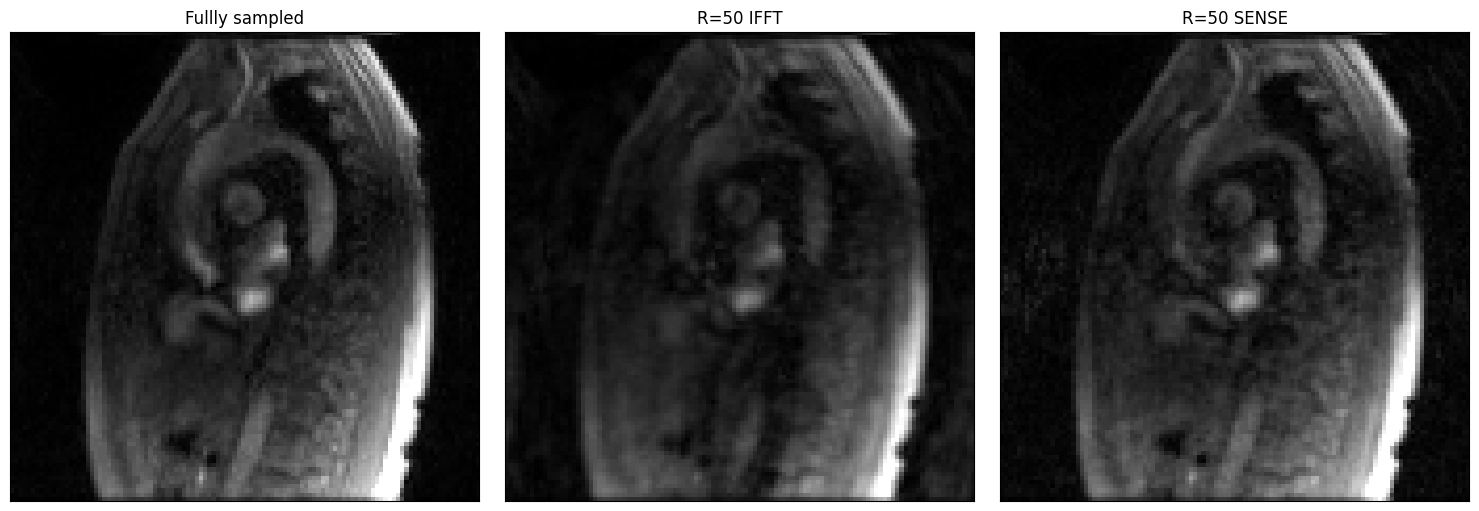

In [ ]:
full = results['full_ifft']
us_ifft = results['us_ifft']
us_sense = results['us_sense']
mid = full.shape[0] // 2 - 3
vmax = np.percentile(np.stack([full, us_ifft, us_sense]), 99.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(full[mid].T, cmap='gray', vmax=vmax)
axes[0].set_title('Fully sampled')
axes[1].imshow(us_ifft[mid].T, cmap='gray', vmax=vmax)
axes[1].set_title(f'R={acceleration} IFFT')
axes[2].imshow(us_sense[mid].T, cmap='gray', vmax=vmax)
axes[2].set_title(f'R={acceleration} SENSE')
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()
